Amostras: (14500, 10)
Target
1    11478
4     2155
5      809
3       39
2       13
6        4
7        2
Name: count, dtype: int64

🔍 Matriz de Confusão:
[[3442    0    1    0    0    0    0]
 [   0    2    0    2    0    0    0]
 [   4    0    8    0    0    0    0]
 [   0    0    0  646    0    0    0]
 [   1    0    2    0  239    1    0]
 [   0    0    0    0    0    1    0]
 [   1    0    0    0    0    0    0]]

Relatório de Classificação:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      3443
           2       1.00      0.50      0.67         4
           3       0.73      0.67      0.70        12
           4       1.00      1.00      1.00       646
           5       1.00      0.98      0.99       243
           6       0.50      1.00      0.67         1
           7       0.00      0.00      0.00         1

    accuracy                           1.00      4350
   macro avg       0.75      0.74      0.72      4350
weighte

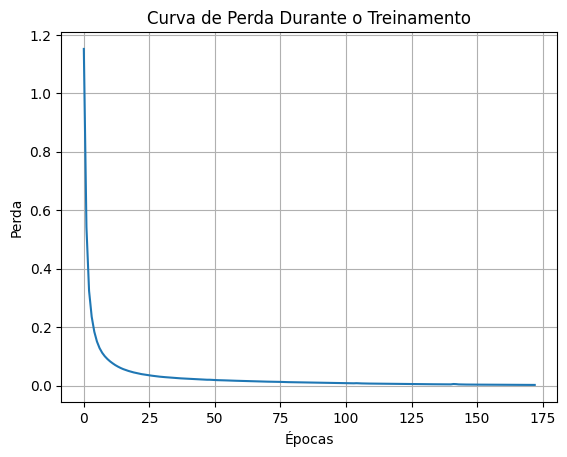

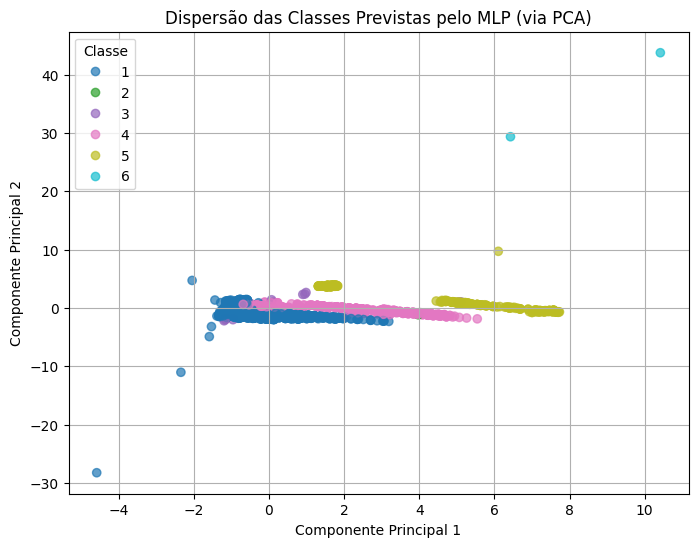

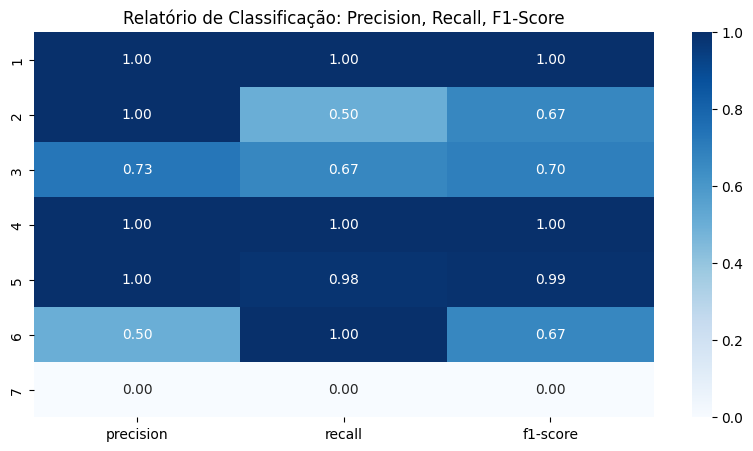

In [6]:
# 1. Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# 2. Carregar dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/shuttle/shuttle.tst"
columns = [f"Attr{i}" for i in range(1, 10)] + ["Target"]
df = pd.read_csv(url, sep=r"\s+", header=None, names=columns)

# 3. Verificar os dados
print("Amostras:", df.shape)
print(df["Target"].value_counts())

# 4. Separar atributos e alvo
X = df.drop("Target", axis=1)
y = df["Target"]

# 5. Normalização
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# 6. Separar treino e teste (30% para teste, com estratificação)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.3, random_state=42, stratify=y
)

# 7. Treinar o MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=300,
    activation='relu',
    solver='adam',
    random_state=42
)
mlp.fit(X_train, y_train)

# 8. Avaliação
y_pred = mlp.predict(X_test)

print("\n🔍 Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, zero_division=0))

print(f"\n✅ Acurácia: {accuracy_score(y_test, y_pred):.4f}")

# 9. Curva de perda
plt.plot(mlp.loss_curve_)
plt.title("Curva de Perda Durante o Treinamento")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.grid(True)
plt.show()

# 10. Gráfico de dispersão com PCA (redução para 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classe")
plt.title("Dispersão das Classes Previstas pelo MLP (via PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

# 11. Gráfico do relatório de classificação (heatmap)
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose().drop(index=["accuracy", "macro avg", "weighted avg"])
plt.figure(figsize=(10, 5))
sns.heatmap(report_df.iloc[:, :3], annot=True, cmap="Blues", fmt=".2f")
plt.title("Relatório de Classificação: Precision, Recall, F1-Score")
plt.show()
